In [189]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

In [190]:
np.random.seed(42)
X = np.random.rand(100,1) - 0.5
y = 3 * X[:, 0]**2 + 0.05 * np.random.randn(100)

In [191]:
df = pd.DataFrame({'X': X.reshape(100), 'y':y })

In [192]:
df['pred1'] = df['y'].mean()

In [193]:
df['res1'] = df['y'] - df['pred1']

In [194]:
df.head()

,X,y,pred1,res1
0,-0.125460,0.051573,0.265458,-0.213885
1,0.450714,0.594480,0.265458,0.329021
2,0.231994,0.166052,0.265458,-0.099407
3,0.098658,-0.070178,0.265458,-0.335636
4,-0.343981,0.343986,0.265458,0.078528


In [195]:
tree1 = DecisionTreeRegressor(max_leaf_nodes=2)

In [196]:
tree1.fit(df['X'].values.reshape(-1,1), df['res1'].values)

DecisionTreeRegressor(max_leaf_nodes=2)

In [197]:
df['pred2'] = df['pred1'] + tree1.predict(df['X'].values.reshape(-1,1))

In [198]:
df['res2'] = df['y'] - df['pred2']

In [199]:
df.head()

,X,y,pred1,res1,pred2,res2
0,-0.125460,0.051573,0.265458,-0.213885,0.197652,-0.146079
1,0.450714,0.594480,0.265458,0.329021,0.197652,0.396828
2,0.231994,0.166052,0.265458,-0.099407,0.197652,-0.031600
3,0.098658,-0.070178,0.265458,-0.335636,0.197652,-0.267830
4,-0.343981,0.343986,0.265458,0.078528,0.197652,0.146334


In [200]:
tree2 = DecisionTreeRegressor(max_leaf_nodes=8)
tree2.fit(df['X'].values.reshape(-1, 1), df['res2'].values)

DecisionTreeRegressor(max_leaf_nodes=8)

**Recursive gradient boosting**

In [201]:
def gradient_boost(X, y, number, lr, count=1, regs=None, foo=None):
  if regs is None:
    regs = []
  if number == 0:
    return
  if count > 1:
    y = y - regs[-1].predict(X)
  else:
    foo = y.copy()
  tree = DecisionTreeRegressor(max_depth=5, random_state=42)
  tree.fit(X, y)
  regs.append(tree)

  X_test = np.linspace(-0.5, 0.5, 500).reshape(-1, 1)
  y_pred = sum(lr * reg.predict(X_test) for reg in regs)

  plt.figure(figsize=(6,4))
  plt.plot(X_test, y_pred, linewidth=2, label=f'Round{count}')
  plt.plot(X[:, 0], foo, 'r.', label='Actual')
  plt.title(f'Gradient boost - Round{count}')
  plt.legend()
  plt.tight_layout()
  plt.show()

  gradient_boost(X, y, number - 1, lr, count + 1, regs, foo)

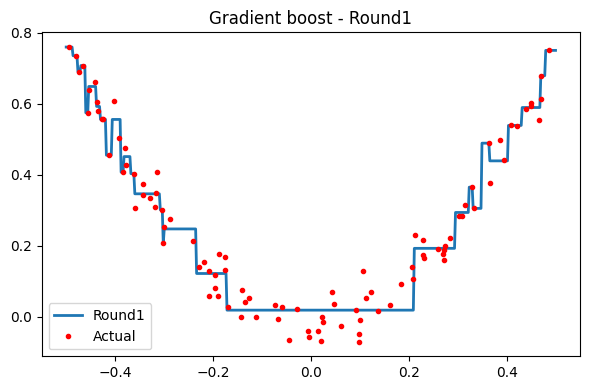

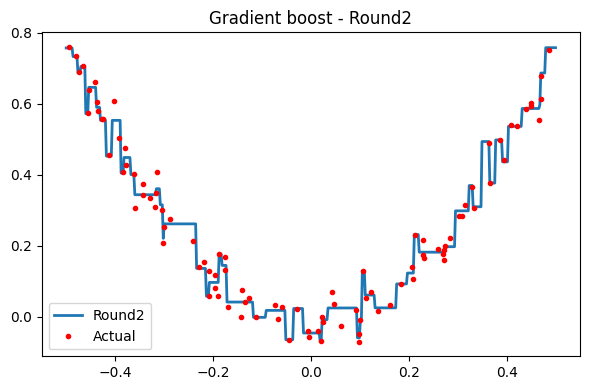

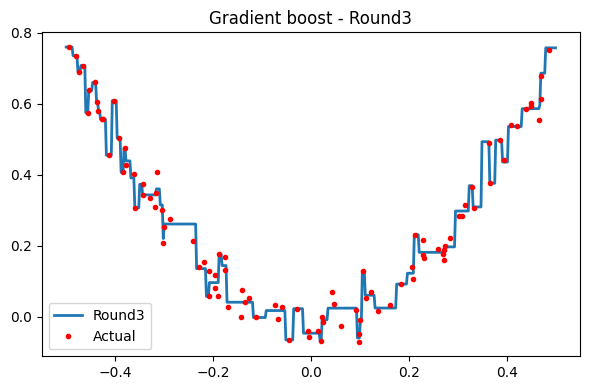

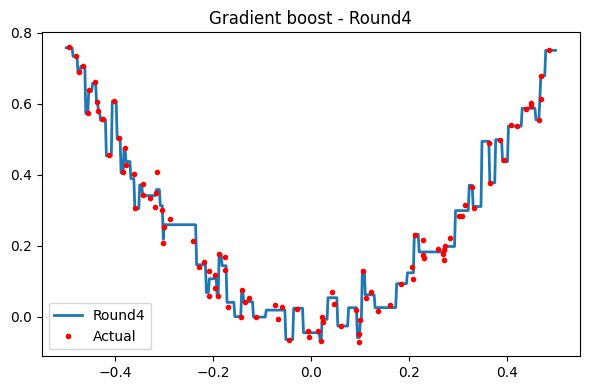

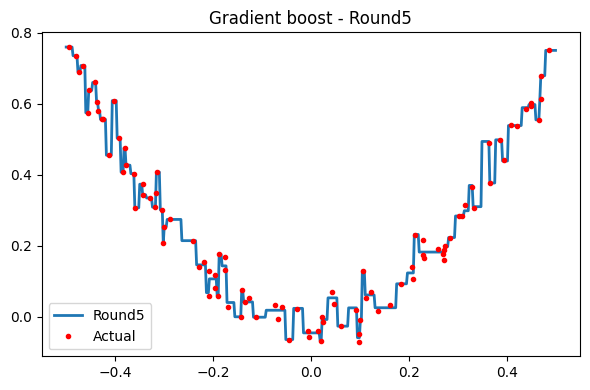

In [202]:
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3 * X[:, 0]**2 + 0.05 * np.random.randn(100)

gradient_boost(X, y, number=5, lr=1)